In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [89]:
class LinearRegression:
    # fit to pass data adam for optimization
    def __init__(self):
        self.error = None
        self._y = None
        self.b = None
        self.w = None
        self.y = None
        self.x = None
        self.w_error = None
        self.b_error = None
        self.m_w = None
        self.m_b = None
        self.v_w = None
        self.v_b = None
        self.r_v_w = None
        self.r_v_b = None
        self.hat_m_w = None
        self.hat_m_b = None
        self.epoch_count = 1
        self.epoch_limit = None
        self.hat_v_w = None
        self.hat_v_b = None
        self.update_step = lambda: None
        self.metrics = self.Metrics(self)
    def fit(self,xs,ys,epochs = 100,optimizer = "RMSprop"):
        self.x = xs.copy()
        self.y = ys.copy()
        self.w = np.zeros(self.x.shape[1])
        self.b = 0.0
        self.v_w = np.zeros(self.x.shape[1])
        self.m_w = np.zeros(self.x.shape[1])
        self.m_b = 0
        self.v_b = 0
        self._y = np.dot(self.x , self.w) + self.b
        self.error = np.mean((self._y - self.y)**2)
        self.b_error = 2*np.mean(self._y - self.y)
        self.w_error = 2*np.dot(self.x.transpose(),self._y - self.y)/self.x.shape[0]
        self.epoch_limit = epochs
        if optimizer == "adam":
            update_step = self.adam
        elif optimizer == "RMSprop":
            update_step = self.RMSprop
        elif optimizer == "momentum":
            update_step = self.momentum
        else:
            raise ValueError(f"Unknown optimizer: {optimizer}")
        while self.epoch_count <= self.epoch_limit:
            update_step()
            self._y = np.dot(self.x , self.w) + self.b
            self.error = np.mean((self._y - self.y)**2)
            self.b_error = 2*np.mean(self._y - self.y)
            self.w_error = 2*np.dot(self.x.transpose(),self._y - self.y)/self.x.shape[0]
            self.metrics = self.Metrics(self)
            self.epoch_count += 1
            print(f"Epochs {self.epoch_count -1} / {self.epoch_limit} | loss : {self.error}")
    def adam(self, beta1 = 0.9 , beta2 = 0.999 ,epsilon = 10**-8,gamma = 0.001):
        #momentum variables
        self.m_w = beta1*self.m_w + (1 - beta1)*self.w_error
        self.m_b = beta1*self.m_b + (1 - beta1)*self.b_error
        #RMSpropFactors
        self.v_w = beta2*self.v_w + (1-beta2)*(self.w_error**2)
        self.v_b = beta2*self.v_b + (1-beta2)*(self.b_error**2)
        #bias correcting the variance values
        self.hat_v_w = self.v_w / (1 - beta2**self.epoch_count)
        self.hat_v_b = self.v_b / (1 - beta2**self.epoch_count)
        #RMSpropFactvectors for updating the final values
        self.r_v_w = 1 / (np.sqrt(self.hat_v_w + epsilon))
        self.r_v_b = 1 / (np.sqrt(self.hat_v_b + epsilon))
        #bias correcting the momentum values
        self.hat_m_w = self.m_w / (1 - beta1**self.epoch_count)
        self.hat_m_b = self.m_b / (1 - beta1**self.epoch_count)
        #Updating the final value
        self.b = self.b - self.hat_m_b*self.r_v_b*gamma
        self.w = self.w - np.multiply(self.hat_m_w,self.r_v_w)*gamma
    def RMSprop(self,beta2 = 0.999,epsilon = 10**-8, gamma = 0.001):
        self.v_w = beta2*self.v_w + (1-beta2)*(self.w_error**2)
        self.v_b = beta2*self.v_b + (1-beta2)*(self.b_error**2)
        self.hat_v_w = self.v_w / (1 - beta2**self.epoch_count)
        self.hat_v_b = self.v_b / (1 - beta2**self.epoch_count)
        self.r_v_w = 1 / (np.sqrt(self.hat_v_w + epsilon))
        self.r_v_b = 1 / (np.sqrt(self.hat_v_b + epsilon))
        self.b = self.b - self.b_error*self.r_v_b*gamma
        self.w = self.w - np.multiply(self.w_error,self.r_v_w)*gamma
    def momentum(self,beta1 = 0.9 , gamma = 0.001):
        self.m_w = beta1*self.m_w + (1 - beta1)*self.w_error
        self.m_b = beta1*self.m_b + (1 - beta1)*self.b_error
        self.hat_m_w = self.m_w / (1 - beta1**self.epoch_count)
        self.hat_m_b = self.m_b / (1 - beta1**self.epoch_count)
        self.b = self.b - self.hat_m_b*gamma
        self.w = self.w - self.hat_m_w*gamma
    def predict(self,x):
        out = np.dot(x , self.w) + self.b
        return out
    class Metrics:
        def __init__(self,outer):
            self.parameters = None
            self.outer = outer
            self.w = self.outer.w
            self.b = self.outer.b
        def params(self):
            self.parameters = np.append(self.w , [self.b], axis = None)
            return self.parameters
        def r2_score(self, x, y):
            y_pred = self.outer.predict(x)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            return 1 - (ss_res / ss_tot)


In [90]:

df = pd.read_csv('Iris.csv')
training_df = df
x_variable = training_df.loc[:,['SepalLengthCm','SepalWidthCm']]
y_variable = training_df.loc[:,['PetalLengthCm']]
x_train,x_test,y_train,y_test = train_test_split(x_variable, y_variable, test_size = 0.10)

Epochs 1 / 7000 | loss : 17.181644582384695
Epochs 2 / 7000 | loss : 17.169447348054625
Epochs 3 / 7000 | loss : 17.157260140618547
Epochs 4 / 7000 | loss : 17.145082951835604
Epochs 5 / 7000 | loss : 17.132915773467136
Epochs 6 / 7000 | loss : 17.120758597276705
Epochs 7 / 7000 | loss : 17.1086114150301
Epochs 8 / 7000 | loss : 17.09647421849532
Epochs 9 / 7000 | loss : 17.084346999442594
Epochs 10 / 7000 | loss : 17.07222974964435
Epochs 11 / 7000 | loss : 17.060122460875263
Epochs 12 / 7000 | loss : 17.048025124912215
Epochs 13 / 7000 | loss : 17.035937733534315
Epochs 14 / 7000 | loss : 17.023860278522907
Epochs 15 / 7000 | loss : 17.011792751661535
Epochs 16 / 7000 | loss : 16.999735144735997
Epochs 17 / 7000 | loss : 16.987687449534295
Epochs 18 / 7000 | loss : 16.97564965784668
Epochs 19 / 7000 | loss : 16.963621761465618
Epochs 20 / 7000 | loss : 16.951603752185804
Epochs 21 / 7000 | loss : 16.939595621804173
Epochs 22 / 7000 | loss : 16.9275973621199
Epochs 23 / 7000 | loss : 

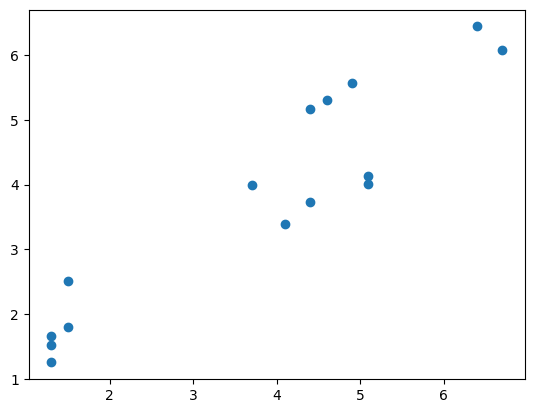

In [91]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
x_train_scaled = scaler.fit_transform(x_train.values)

# --- IMPORTANT ---
# Use that *same* scaler to transform your test data
x_test_scaled = scaler.transform(x_test.values)

# Now, train your model on the SCALED data
model = LinearRegression()
model.fit(x_train_scaled, y_train.values.ravel(), epochs = 7000)

# And predict on the SCALED test data
predictions = model.predict(x_test_scaled)

# Now plot your results
plt.scatter(y_test, predictions)

In [92]:
print(model.metrics.r2_score(x_test_scaled,y_test.values.ravel()),"\n")



0.8738203664867452 

